In [53]:
import pandas as pd

### LOAD DATA

In [91]:
df=pd.read_excel("Employee Sample Data - A.xlsx")

In [92]:
print(df.to_string())

       EEID             Full Name                       Job Title       Department           Business Unit  Gender  Ethnicity   Age  Hire Date  Annual Salary  Bonus %        Country            City  Exit Date
0    E02387           Emily Davis                      Sr. Manger               IT  Research & Development  Female      Black  55.0 2016-04-08       141604.0     0.15  United States         Seattle 2021-10-16
1    E04105         Theodore Dinh             Technical Architect               IT           Manufacturing    Male      Asian  59.0 1997-11-29        99975.0     0.00          China       Chongqing        NaT
2    E02572          Luna Sanders                        Director          Finance     Speciality Products  Female  Caucasian  50.0 2006-10-26       163099.0     0.20  United States         Chicago        NaT
3    E02832       Penelope Jordan        Computer Systems Manager               IT           Manufacturing  Female  Caucasian  26.0 2019-09-27        84913.0     0.

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   EEID           1000 non-null   object        
 1   Full Name      998 non-null    object        
 2   Job Title      999 non-null    object        
 3   Department     998 non-null    object        
 4   Business Unit  1000 non-null   object        
 5   Gender         999 non-null    object        
 6   Ethnicity      993 non-null    object        
 7   Age            994 non-null    float64       
 8   Hire Date      993 non-null    datetime64[ns]
 9   Annual Salary  989 non-null    float64       
 10  Bonus %        992 non-null    float64       
 11  Country        998 non-null    object        
 12  City           998 non-null    object        
 13  Exit Date      85 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(3), object(9)
memory usage: 109.5+ KB


### CLEAN DATA

In [94]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [95]:
df.isnull()

,EEID,Full Name,Job Title,Department,Business Unit,Gender,Ethnicity,Age,Hire Date,Annual Salary,Bonus %,Country,City,Exit Date
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False,False,False,True
996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False,False,False,True
998,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [96]:
df.isnull().sum()

EEID               0
Full Name          2
Job Title          1
Department         2
Business Unit      0
Gender             1
Ethnicity          7
Age                6
Hire Date          7
Annual Salary     11
Bonus %            8
Country            2
City               2
Exit Date        915
dtype: int64

In [97]:
df['Is_Exited'] = df['Exit Date'].notnull().astype(int)

In [98]:
df['Age']=df['Age'].fillna(df['Age'].median())
df['Annual Salary']=df['Annual Salary'].fillna(df['Annual Salary'].median())
df['Bonus %']=df['Bonus %'].fillna(df['Bonus %'].median())

In [99]:
df['Age'].median()

45.0

In [100]:
df.isnull().sum()

EEID               0
Full Name          2
Job Title          1
Department         2
Business Unit      0
Gender             1
Ethnicity          7
Age                0
Hire Date          7
Annual Salary      0
Bonus %            0
Country            2
City               2
Exit Date        915
Is_Exited          0
dtype: int64

In [101]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Country'] = df['Country'].fillna(df['Country'].mode()[0])

df['Department'] = df['Department'].fillna(df['Department'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])
df['Ethnicity'] = df['Ethnicity'].fillna(df['Ethnicity'].mode()[0])
df['Job Title'] = df['Job Title'].fillna(df['Job Title'].mode()[0])

df['Hire Date'] = df['Hire Date'].fillna(df['Hire Date'].median())

In [102]:
df.isnull().sum()

EEID               0
Full Name          2
Job Title          0
Department         0
Business Unit      0
Gender             0
Ethnicity          0
Age                0
Hire Date          0
Annual Salary      0
Bonus %            0
Country            0
City               0
Exit Date        915
Is_Exited          0
dtype: int64

In [103]:
df = df.dropna(subset=['Full Name'])

In [104]:
df.isnull().sum()

EEID               0
Full Name          0
Job Title          0
Department         0
Business Unit      0
Gender             0
Ethnicity          0
Age                0
Hire Date          0
Annual Salary      0
Bonus %            0
Country            0
City               0
Exit Date        913
Is_Exited          0
dtype: int64

In [105]:
df = df.drop(columns=['Exit Date'])

In [106]:
df.isnull().sum()

EEID             0
Full Name        0
Job Title        0
Department       0
Business Unit    0
Gender           0
Ethnicity        0
Age              0
Hire Date        0
Annual Salary    0
Bonus %          0
Country          0
City             0
Is_Exited        0
dtype: int64

### Modify the first 5 rows

In [107]:
for i in df.head().index:
    df.loc[i, 'Annual Salary']=1000

In [108]:
df.loc[0:4, 'Age'] = [25, 30, 28, 35, 32]
df.loc[0:4, 'Department'] = ['HR', 'IT', 'Finance', 'IT', 'HR']

In [109]:
df.head()

,EEID,Full Name,Job Title,Department,Business Unit,Gender,Ethnicity,Age,Hire Date,Annual Salary,Bonus %,Country,City,Is_Exited
0,E02387,Emily Davis,Sr. Manger,HR,Research & Development,Female,Black,25.0,2016-04-08,1000.0,0.15,United States,Seattle,1
1,E04105,Theodore Dinh,Technical Architect,IT,Manufacturing,Male,Asian,30.0,1997-11-29,1000.0,0.00,China,Chongqing,0
2,E02572,Luna Sanders,Director,Finance,Speciality Products,Female,Caucasian,28.0,2006-10-26,1000.0,0.20,United States,Chicago,0
3,E02832,Penelope Jordan,Computer Systems Manager,IT,Manufacturing,Female,Caucasian,35.0,2019-09-27,1000.0,0.07,United States,Chicago,0
4,E01639,Austin Vo,Sr. Analyst,HR,Manufacturing,Male,Asian,32.0,1995-11-20,1000.0,0.00,United States,Phoenix,0


### largest salary.

In [110]:
df['Annual Salary'].max()

258498.0

### Group the data by department

In [111]:
new_df=df.groupby('Department')

In [112]:
new_df['Age'].mean()
new_df['Annual Salary'].mean()

Department
Accounting         123146.947917
Engineering        108439.974522
Finance            121855.915966
HR                   1000.000000
Human Resources    117907.088710
IT                  96787.691667
Marketing          129663.033333
Sales              111120.635714
Name: Annual Salary, dtype: float64

### Group the data by department+ethnicity

In [113]:
newdf=df.groupby(['Department','Ethnicity'])

In [114]:
newdf['Age'].max()
newdf['Age'].min()
newdf['Annual Salary'].median()

Department       Ethnicity
Accounting       Asian        114893.0
                 Black         91853.0
                 Caucasian    121159.5
                 Latino        92317.0
Engineering      Asian         91782.0
                 Black         74412.0
                 Caucasian     95639.0
                 Latino        96818.0
Finance          Asian        124928.0
                 Black        131652.0
                 Caucasian     95045.0
                 Latino       124553.0
HR               Asian          1000.0
                 Black          1000.0
Human Resources  Asian        125871.5
                 Black        142318.0
                 Caucasian    100364.5
                 Latino       101985.0
IT               Asian         90396.5
                 Black         72901.5
                 Caucasian     81069.5
                 Latino        83403.0
Marketing        Asian        147752.0
                 Black         86075.5
                 Caucasian    113135.

In [115]:
df.to_excel('cleaned_data.xlsx', index=False)

In [116]:
df

,EEID,Full Name,Job Title,Department,Business Unit,Gender,Ethnicity,Age,Hire Date,Annual Salary,Bonus %,Country,City,Is_Exited
0,E02387,Emily Davis,Sr. Manger,HR,Research & Development,Female,Black,25.0,2016-04-08,1000.0,0.15,United States,Seattle,1
1,E04105,Theodore Dinh,Technical Architect,IT,Manufacturing,Male,Asian,30.0,1997-11-29,1000.0,0.00,China,Chongqing,0
2,E02572,Luna Sanders,Director,Finance,Speciality Products,Female,Caucasian,28.0,2006-10-26,1000.0,0.20,United States,Chicago,0
3,E02832,Penelope Jordan,Computer Systems Manager,IT,Manufacturing,Female,Caucasian,35.0,2019-09-27,1000.0,0.07,United States,Chicago,0
4,E01639,Austin Vo,Sr. Analyst,HR,Manufacturing,Male,Asian,32.0,1995-11-20,1000.0,0.00,United States,Phoenix,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,E03094,Wesley Young,Sr. Analyst,Marketing,Speciality Products,Male,Caucasian,33.0,2016-09-18,98427.0,0.00,United States,Columbus,0
996,E01909,Lillian Khan,Analyst,Finance,Speciality Products,Female,Asian,44.0,2010-05-31,47387.0,0.00,China,Chengdu,1
997,E04398,Oliver Yang,Director,Marketing,Speciality Products,Male,Asian,31.0,2019-06-10,176710.0,0.15,United States,Miami,0
998,E02521,Lily Nguyen,Sr. Analyst,Finance,Speciality Products,Female,Asian,33.0,2012-01-28,95960.0,0.00,China,Chengdu,0


## Visualization

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

### Visualization using **CountPlot**

<Axes: xlabel='Gender', ylabel='count'>

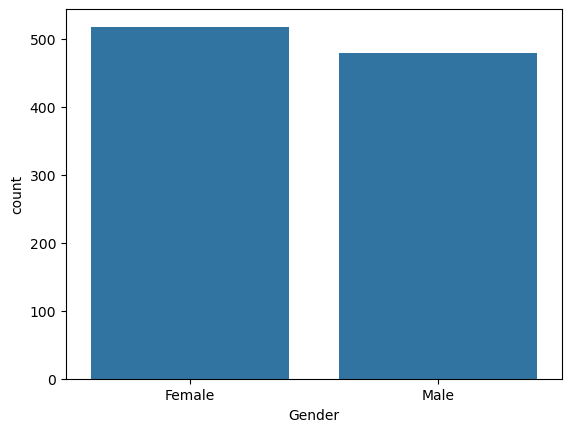

In [118]:
sns.countplot(x="Gender", data=df)

<Axes: xlabel='count', ylabel='Department'>

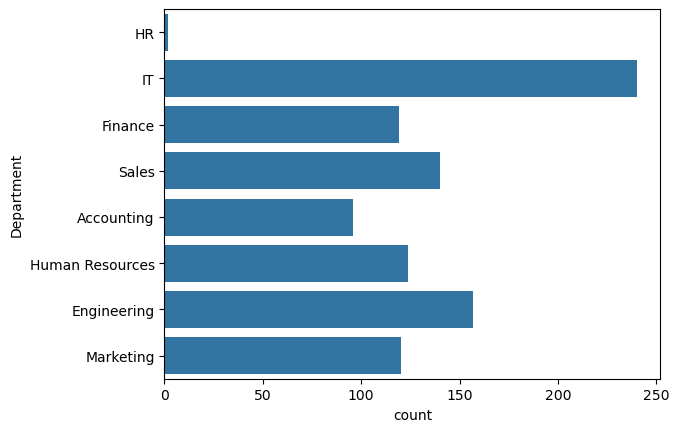

In [120]:
sns.countplot(y='Department',data=df)

<Axes: xlabel='count', ylabel='Country'>

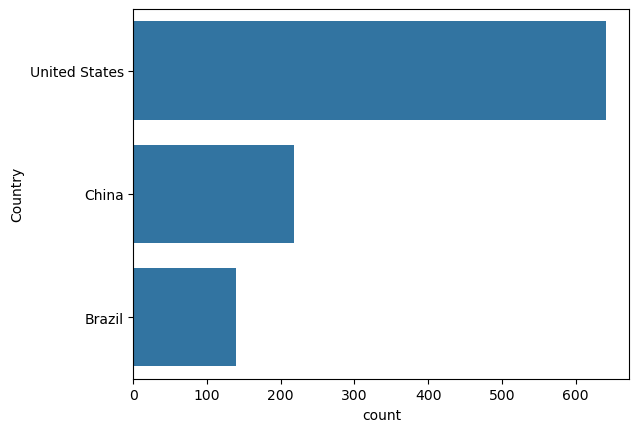

In [122]:
sns.countplot(y='Country',data=df)

<Axes: xlabel='count', ylabel='Department'>

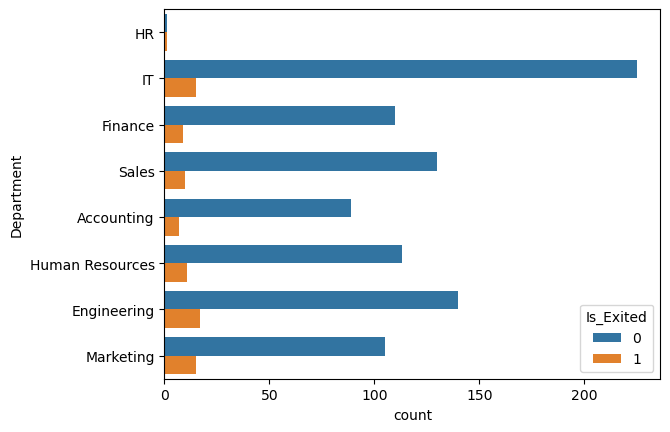

In [126]:
sns.countplot(y='Department',hue='Is_Exited',data=df)

### Visualization using **ScatterPlot**

<function matplotlib.pyplot.show(close=None, block=None)>

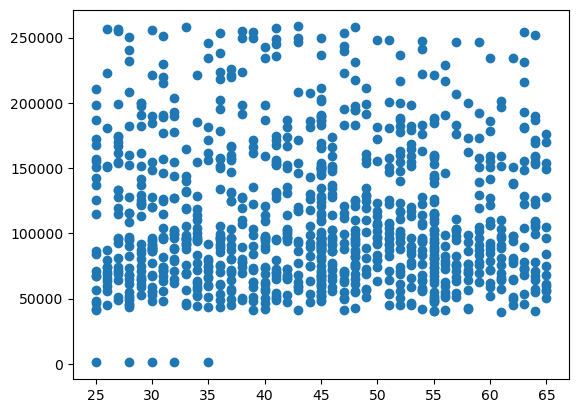

In [121]:
plt.scatter(y='Annual Salary',x='Age',data=df)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

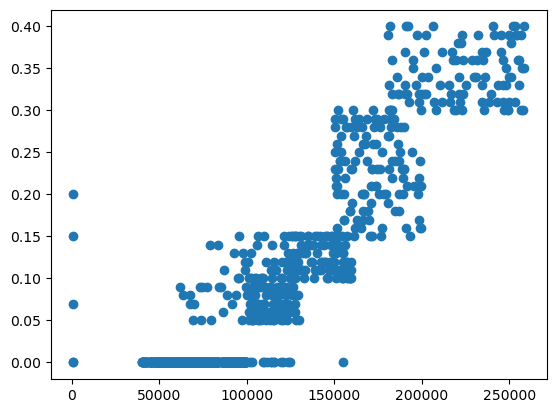

In [123]:
plt.scatter(x='Annual Salary',y='Bonus %',data=df)
plt.show

### Visualization using **HeatMap**

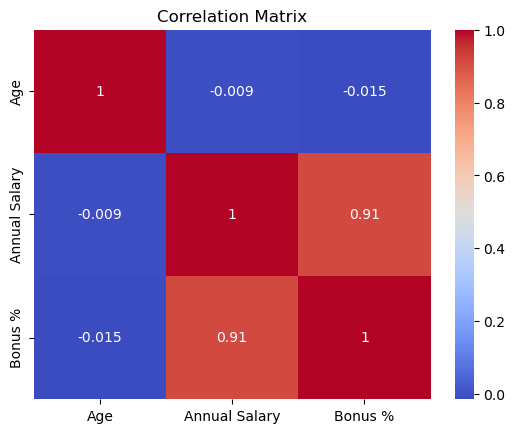

In [124]:
numeric_df = df[["Age", "Annual Salary", "Bonus %"]]

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

### Visualization using **BoxPlot**

<Axes: xlabel='Bonus %', ylabel='Department'>

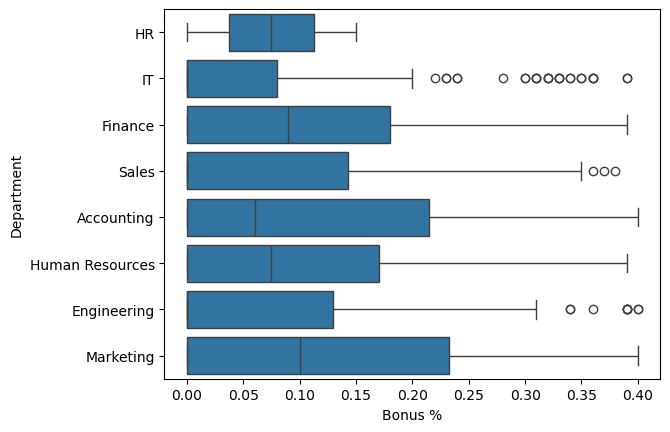

In [125]:
sns.boxplot(x='Bonus %',y='Department',data=df)

<Axes: xlabel='Annual Salary', ylabel='Department'>

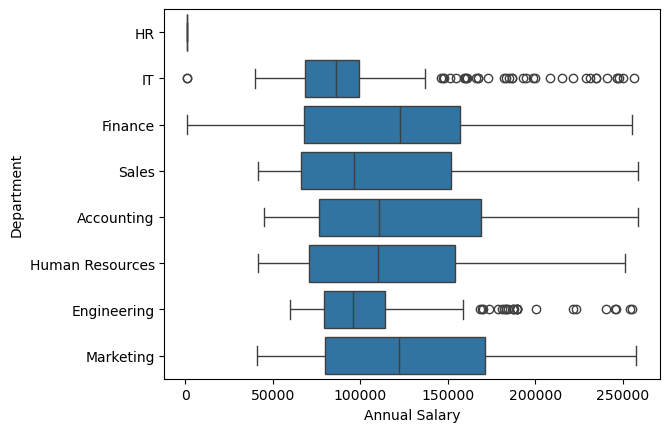

In [119]:
sns.boxplot(x='Annual Salary',y='Department',data=df)